In [ ]:
#importing tools and technologies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Loading the DataSet
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Checking Dataset Shape and Structure
print("--- Dataset Overview ---")
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())




--- Dataset Overview ---
Dataset Shape: (7043, 21)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7

In [ ]:
#handling missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)


C:\Users\heman\AppData\Local\Temp\ipykernel_19724\1504401361.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)



--- Numerical Features Summary ---
Numerical Features: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

--- Categorical Features Summary ---
Categorical Features: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


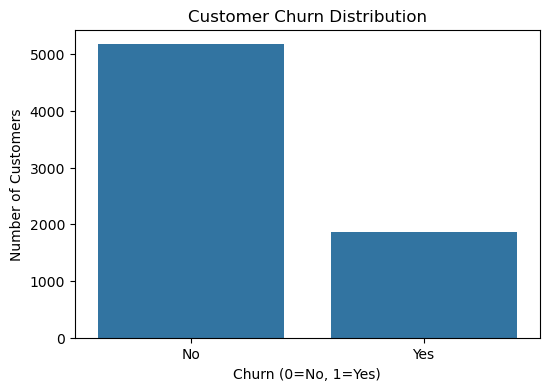


Logistic Regression performance:
Accuracy: 0.815471965933286
Recall: 0.579088471849866
Precision: 0.677115987460815
F1-Score:  0.6242774566473989

Decision Tree performance:
Accuracy: 0.7246273953158269
Recall: 0.4932975871313673
Precision: 0.4804177545691906
F1-Score:  0.48677248677248675

Random Forest performance:
Accuracy: 0.7955997161107168
Recall: 0.4745308310991957
Precision: 0.6579925650557621
F1-Score:  0.5514018691588785

Support Vector Machine performance:
Accuracy: 0.8069552874378992
Recall: 0.5013404825737265
Precision: 0.684981684981685
F1-Score:  0.5789473684210527
Logistic Regression Accuracy: 0.815471965933286
Decision Tree Accuracy: 0.7246273953158269
Random Forest Accuracy: 0.7955997161107168
SVM Accuracy: 0.8069552874378992
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80

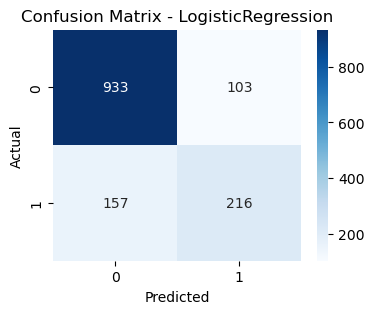

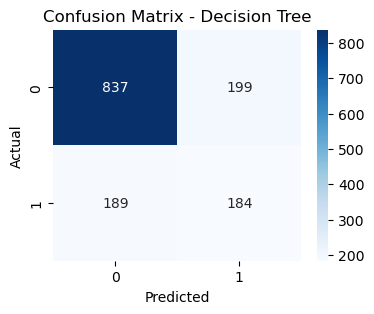

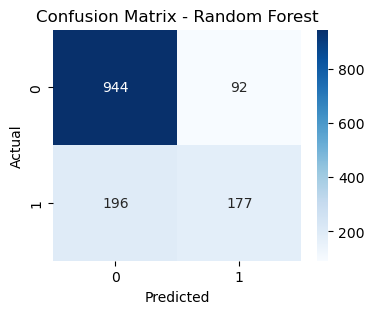


--- Model Comparison ---
                        Accuracy  Precision    Recall  F1-Score
Logistic Regression     0.815472   0.677116  0.579088  0.624277
Decision Tree           0.724627   0.480418  0.493298  0.486772
Random Forest           0.795600   0.657993  0.474531  0.551402
Support Vector Machine  0.806955   0.684982  0.501340  0.578947

Best Model based on F1-Score: Logistic Regression

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409


Prediction Customer is NOT likely to churn


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#Analyzing the numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
print("\n--- Numerical Features Summary ---")
print("Numerical Features:", numerical_features)
print("\n--- Categorical Features Summary ---")
print("Categorical Features:", categorical_features)
df[numerical_features].describe()
df[categorical_features].describe() 

#Visualizing the churn distribution
df['Churn'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.show()

#converting categorical variables using label endoding/ one-hot encoding
label_encoder= LabelEncoder()
for column in categorical_features:
    df[column] = label_encoder.fit_transform(df[column])

#feature scaling and StandardScaler
x=df.drop('Churn', axis=1)
y=df['Churn']
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

#Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

                    #Model Building
#Logistic Regression
lr= LogisticRegression()
lr.fit(x_train, y_train)
lr_pred= lr.predict(x_test)

#Decision Tree Classifier
dt= DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred= dt.predict(x_test)

#Random Forest Classifier
rf= RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred= rf.predict(x_test)

#Support Vector Machine
svm= SVC(kernel='rbf', random_state=42)
svm.fit(x_train, y_train)
svm_pred= svm.predict(x_test)

#model evaluation
def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec= precision_score(y_test, y_pred)
    rec= recall_score(y_test, y_pred)
    f1= f1_score(y_test, y_pred)

    print(f"\n{name} performance:")
    print("Accuracy:", acc)
    print("Recall:", rec)
    print("Precision:",prec)
    print("F1-Score: ",f1)

    return acc, prec, rec, f1

results={}
results['Logistic Regression']= evaluate_model(
    "Logistic Regression", y_test, lr_pred
)
results['Decision Tree']=evaluate_model(
    "Decision Tree", y_test, dt_pred
)
results['Random Forest']=evaluate_model(
    "Random Forest", y_test, rf_pred
)
results['Support Vector Machine'] = evaluate_model(
    "Support Vector Machine", y_test, svm_pred
)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))

#confusion matrix
models={
    "LogisticRegression": lr_pred,
    "Decision Tree":dt_pred,
    "Random Forest": rf_pred,
}
for name, pred in models.items():
    cm=confusion_matrix(y_test, pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

#Model Comaprison
comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n--- Model Comparison ---")
print(comparison_df)

best_model = comparison_df['F1-Score'].idxmax()
print(f"\nBest Model based on F1-Score: {best_model}")

#final classification report for the best model
print(f"\nClassification Report for {best_model}:\n")
if best_model == "Logistic Regression":
    print(classification_report(y_test, lr_pred))
elif best_model == "Decision Tree":
    print(classification_report(y_test, dt_pred))
elif best_model == "Random Forest":
    print(classification_report(y_test, rf_pred))

#sample prediction using the best model
sample_customer=np.array([[1 , 0, 1, 45, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 75, 3500]])
sample_customer_scaled= scaler.transform(sample_customer)

prediction = rf.predict(sample_customer_scaled)

if prediction[0]==1:
    print("\nPrediction: Customer is likely to CHURN")
else:
    print("\nPrediction Customer is NOT likely to churn")